# 06 Model Evaluation
Evaluate models using classification metrics and visualizations.

Train Shape: (16296, 5005)
Test Shape : (4074, 5005)

Models loaded successfully.

Evaluating Logistic Regression...

Evaluating Random Forest...

Evaluating Gradient Boosting...

Evaluating SVM...

=== Model Comparison ===
                 Model  Accuracy  Precision  Recall  F1-Score
3                  SVM    0.8878     0.8715  0.8878    0.8686
0  Logistic Regression    0.8684     0.8513  0.8684    0.8585
2    Gradient Boosting    0.8574     0.8318  0.8574    0.8423
1        Random Forest    0.8223     0.8044  0.8223    0.7900


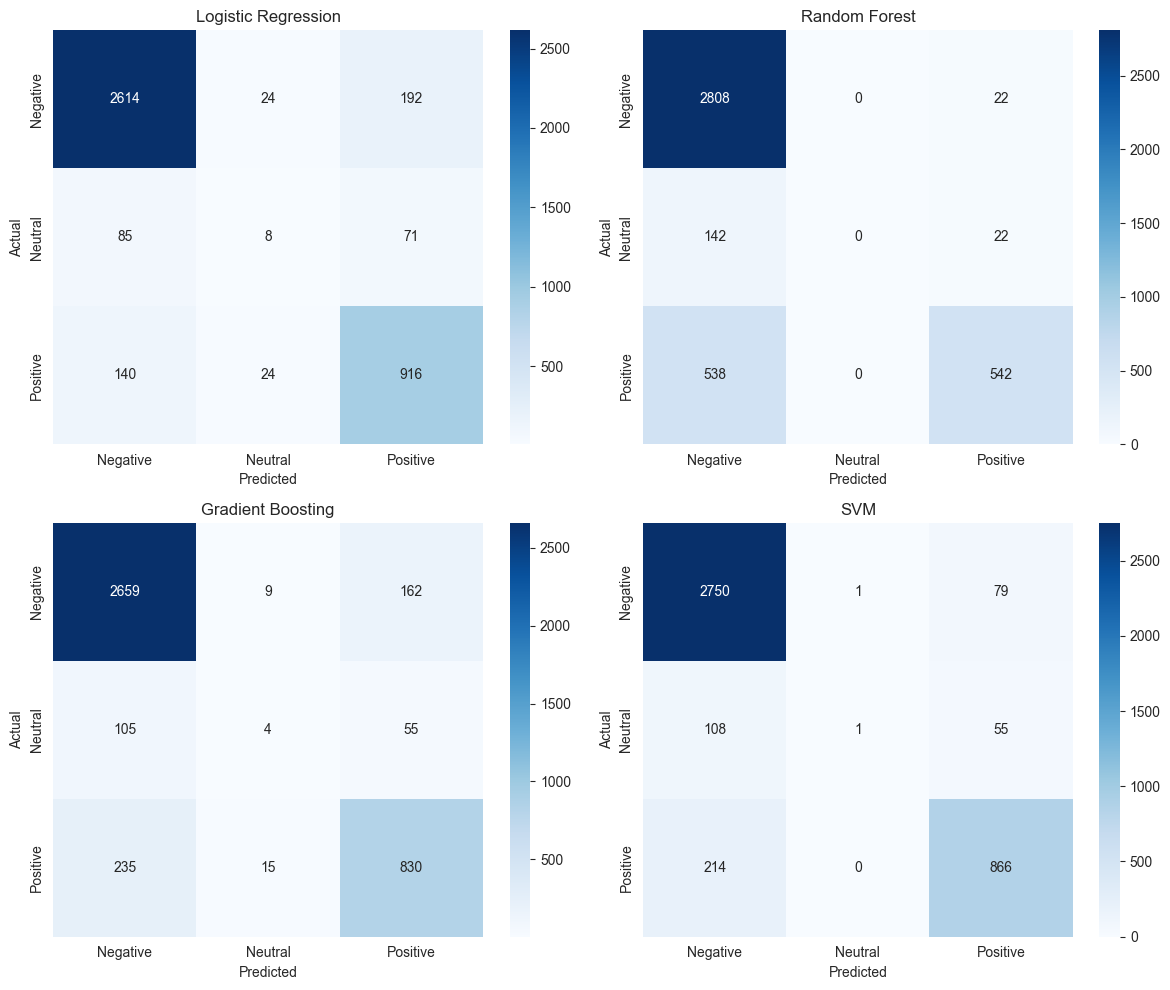


Best Model: SVM

Classification Report:

              precision    recall  f1-score   support

    Negative       0.90      0.97      0.93      2830
     Neutral       0.50      0.01      0.01       164
    Positive       0.87      0.80      0.83      1080

    accuracy                           0.89      4074
   macro avg       0.75      0.59      0.59      4074
weighted avg       0.87      0.89      0.87      4074


Evaluation report saved to: ../assets/reports/evaluation_report.json


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ==========================
# Load Data
# ==========================

X = np.load('../data/combined_features.npy')
y = np.load('../data/labels.npy', allow_pickle=True)

label_map = {
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
}

if y.dtype == object:
    y = pd.Series(y).map(label_map).values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ==========================
# Load Models
# ==========================

models = {
    'Logistic Regression': joblib.load('../models/logistic_regression.joblib'),
    'Random Forest': joblib.load('../models/random_forest.joblib'),
    'Gradient Boosting': joblib.load('../models/gradient_boosting.joblib'),
    'SVM': joblib.load('../models/svm.joblib')
}

print("\nModels loaded successfully.")

# ==========================
# Model Evaluation
# ==========================

results = []

for name, model in models.items():

    print(f"\nEvaluating {name}...")

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    results.append({
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

# ==========================
# Metrics Table
# ==========================

metrics_df = pd.DataFrame(results)
metrics_df = metrics_df.sort_values(
    by='F1-Score',
    ascending=False
)

print("\n=== Model Comparison ===")
print(metrics_df)

# ==========================
# Confusion Matrices
# ==========================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

class_names = [
    'Negative',
    'Neutral',
    'Positive'
]

for idx, (name, model) in enumerate(models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[idx]
    )

    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ==========================
# Best Model Report
# ==========================

best_model_name = metrics_df.iloc[0]['Model']
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

print(f"\nBest Model: {best_model_name}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=class_names
    )
)

# ==========================
# Save Evaluation Report
# ==========================

eval_report = {
    "best_model": best_model_name,
    "metrics": metrics_df.to_dict('records')
}

report_path = "../assets/reports/evaluation_report.json"

Path(report_path).parent.mkdir(
    parents=True,
    exist_ok=True
)

with open(report_path, "w") as f:
    json.dump(eval_report, f, indent=4)

print(f"\nEvaluation report saved to: {report_path}")

In [3]:
print("y_test sample:", y_test[:5])
print("y_pred sample:", list(predictions.values())[0][:5])

print("y_test dtype:", y_test.dtype)

y_test sample: ['Negative' 'Negative' 'Negative' 'Negative' 'Negative']
y_pred sample: [0 0 0 0 0]
y_test dtype: object
